In [44]:
import datetime as dt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import APSIMGraphHelpers as AGH
import GraphHelpers as GH
from scipy import stats
import sqlite3

In [45]:
Roberts = pd.read_excel('CanadaCEData.xlsx',sheet_name='Roberts_etal_1988',header=1)
Roberts.set_index(['Cultivar','TmeanFinal','PpInitial','PpFinal','TmeanInitial','DuratInitial'],drop=False,inplace=True)
Roberts.sort_index(axis=0,inplace=True)
Roberts.sort_index(axis=1,inplace=True)

In [46]:
RobCults = Roberts.index.get_level_values(0).drop_duplicates()
RobInitTemps = Roberts.index.get_level_values(4).drop_duplicates()
RobInitPps = Roberts.index.get_level_values(2).drop_duplicates()
RobFinalTemps = Roberts.index.get_level_values(1).drop_duplicates()
RobFinalPps = Roberts.index.get_level_values(3).drop_duplicates()

In [47]:
RobCults

Index(['Laird', 'Precoz'], dtype='object', name='Cultivar')

In [48]:
RobInitTemps

Index([1, 5, 9], dtype='int64', name='TmeanInitial')

In [49]:
RobInitPps

Index([8, 16], dtype='int64', name='PpInitial')

In [50]:
RobFinalTemps

Index([12, 19], dtype='int64', name='TmeanFinal')

In [51]:
RobFinalPps

Index([11, 16], dtype='int64', name='PpFinal')

In [52]:
cols = dict(zip(RobInitTemps.values,['b','g','r']))
fill = dict(zip(RobInitPps.values,[False,True]))
lins = dict(zip(RobInitPps.values,['o--','o-']))
ylims = dict(zip(RobCults.values,[(500,2000),(300,1000)]))

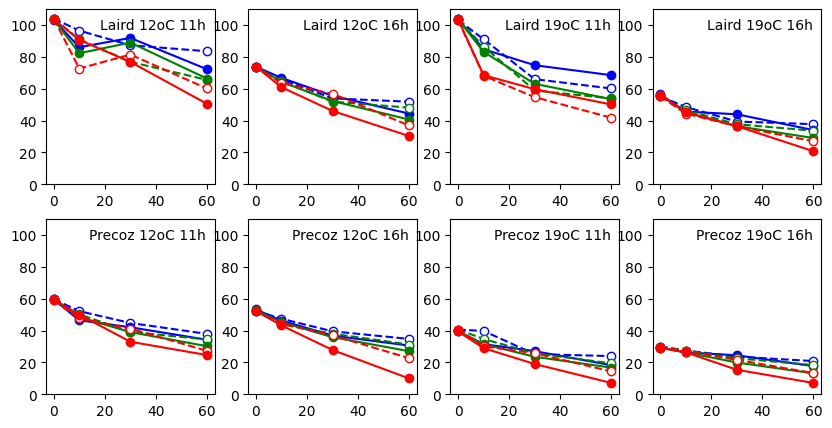

In [53]:
Graph = plt.figure(figsize=(10,5))
pos = 1
for c in RobCults:
    for ft in RobFinalTemps:
        for fp in RobFinalPps:
            ax = Graph.add_subplot(2,4,pos)
            plt.text(0.95,0.95,c+" "+str(ft)+"oC "+str(fp)+"h",horizontalalignment='right',verticalalignment='top', transform=ax.transAxes)
            for it in RobInitTemps:
                for ip in RobInitPps:
                    datfilter = (Roberts.Cultivar==c)&(Roberts.TmeanFinal==ft)&(Roberts.PpFinal==fp)&(Roberts.TmeanInitial==it)&(Roberts.PpInitial==ip)
                    dat = Roberts.loc[datfilter,:]
                    fc = cols[it]
                    ls = lins[ip]
                    if ip == 8:
                        fc = 'w'
                    plt.plot(dat.DuratInitial,dat.DaysToFlowerPostVern,ls,color = cols[it],mfc=fc)
            #plt.ylim(ylims[c][0],ylims[c][1])
            plt.ylim(0,110)
            pos+=1

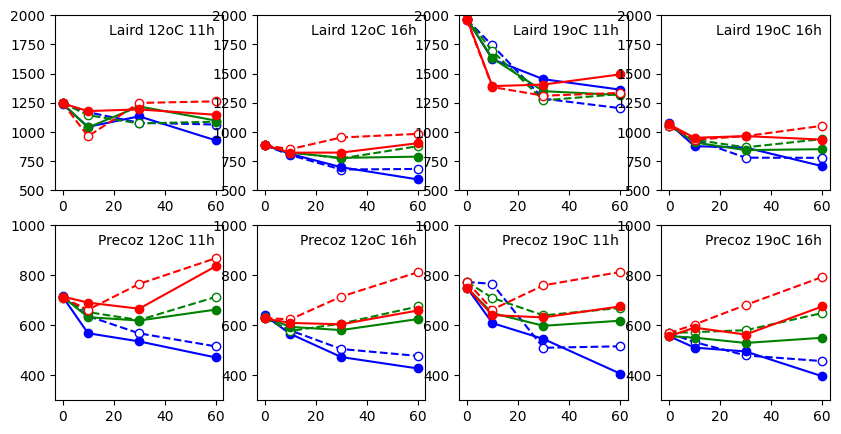

In [54]:
Graph = plt.figure(figsize=(10,5))
pos = 1
for c in RobCults:
    for ft in RobFinalTemps:
        for fp in RobFinalPps:
            ax = Graph.add_subplot(2,4,pos)
            plt.text(0.95,0.95,c+" "+str(ft)+"oC "+str(fp)+"h",horizontalalignment='right',verticalalignment='top', transform=ax.transAxes)
            for it in RobInitTemps:
                for ip in RobInitPps:
                    datfilter = (Roberts.Cultivar==c)&(Roberts.TmeanFinal==ft)&(Roberts.PpFinal==fp)&(Roberts.TmeanInitial==it)&(Roberts.PpInitial==ip)
                    dat = Roberts.loc[datfilter,:]
                    fc = cols[it]
                    ls = lins[ip]
                    if ip == 8:
                        fc = 'w'
                    plt.plot(dat.DuratInitial,dat.TtFirstFlower,ls,color = cols[it],mfc=fc)
            plt.ylim(ylims[c][0],ylims[c][1])
            pos+=1

In [55]:
Summerfield = pd.read_excel('CanadaCEData.xlsx',sheet_name='Summerfield_etal_1985',header=1)
Summerfield.set_index(['Cultivar','TmeanFinal','PpInitial','PpFinal','TmeanInitial','DuratInitial'],drop=False,inplace=True)
Summerfield.sort_index(axis=0,inplace=True)
Summerfield.sort_index(axis=1,inplace=True)

In [56]:
SumCults = Summerfield.index.get_level_values(0).drop_duplicates()
SumInitTemps = Summerfield.index.get_level_values(4).drop_duplicates()
SumInitPps = Summerfield.index.get_level_values(2).drop_duplicates()
SumFinalTemps = Summerfield.index.get_level_values(1).drop_duplicates()
SumFinalPps = Summerfield.index.get_level_values(3).drop_duplicates()
SumInitDurats = Summerfield.index.get_level_values(5).drop_duplicates()

In [57]:
SumCults

Index(['Ethiopia', 'Laird', 'Precoz'], dtype='object', name='Cultivar')

In [58]:
SumInitTemps

Index([1.5], dtype='float64', name='TmeanInitial')

In [59]:
SumInitPps

Index([0], dtype='int64', name='PpInitial')

In [60]:
SumFinalTemps

Index([9.5, 11.2, 12.5, 12.8, 14.8, 15.2, 15.4, 15.8, 18.0, 18.3, 20.0, 21.7], dtype='float64', name='TmeanFinal')

In [61]:
SumFinalPps

Index([10, 13, 16], dtype='int64', name='PpFinal')

In [62]:
SumInitDurats

Index([0, 30], dtype='int64', name='DuratInitial')

In [63]:
cols = dict(zip(SumFinalPps.values,['grey','darkgoldenrod','darkorange']))
fill = dict(zip(SumInitDurats.values,[False,True]))
lins = dict(zip(SumInitDurats.values,['o--','o-']))
#ylims = dict(zip(RobCults.values,[(500,2000),(300,1000)]))

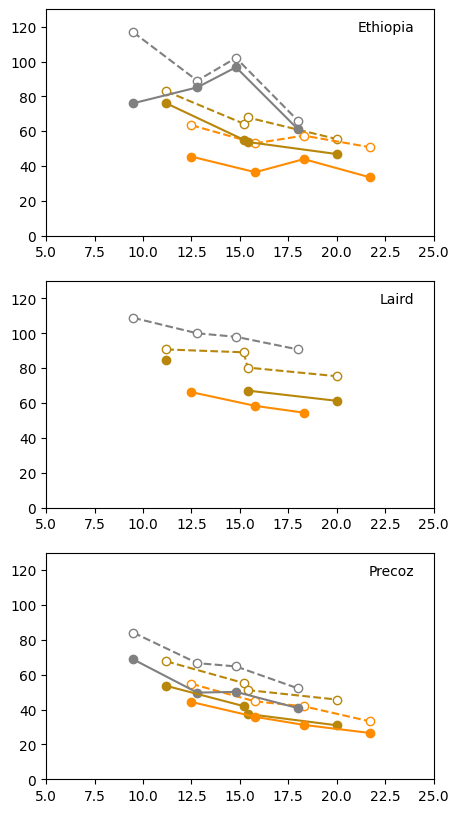

In [64]:
Graph = plt.figure(figsize=(5,10))
pos = 1
for c in SumCults:
    ax = Graph.add_subplot(3,1,pos)
    plt.text(0.95,0.95,c,horizontalalignment='right',verticalalignment='top', transform=ax.transAxes)
    for id in SumInitDurats:
        for fp in SumFinalPps:
            datfilter = (Summerfield.Cultivar==c)&(Summerfield.DuratInitial==id)&(Summerfield.PpFinal==fp)
            dat = Summerfield.loc[datfilter,:]
            fc = cols[fp]
            ls = lins[id]
            if id == 0:
                fc = 'w'
            plt.plot(dat.TmeanFinal,dat.DaysToFlowerPostVern,ls,color = cols[fp],mfc=fc)
    #plt.ylim(ylims[c][0],ylims[c][1])
    plt.ylim(0,130)
    plt.xlim(5,25)
    pos+=1

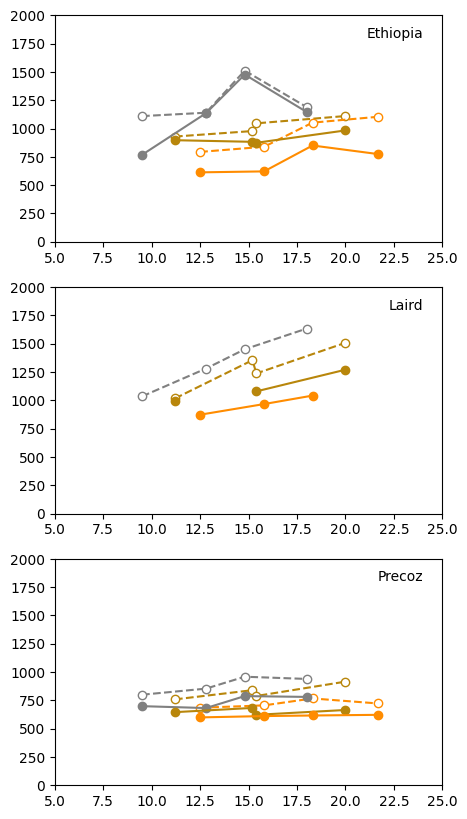

In [65]:
Graph = plt.figure(figsize=(5,10))
pos = 1
for c in SumCults:
    ax = Graph.add_subplot(3,1,pos)
    plt.text(0.95,0.95,c,horizontalalignment='right',verticalalignment='top', transform=ax.transAxes)
    for id in SumInitDurats:
        for fp in SumFinalPps:
            datfilter = (Summerfield.Cultivar==c)&(Summerfield.DuratInitial==id)&(Summerfield.PpFinal==fp)
            dat = Summerfield.loc[datfilter,:]
            fc = cols[fp]
            ls = lins[id]
            if id == 0:
                fc = 'w'
            plt.plot(dat.TmeanFinal,dat.TtFirstFlower,ls,color = cols[fp],mfc=fc)
    #plt.ylim(ylims[c][0],ylims[c][1])
    plt.ylim(0,2000)
    plt.xlim(5,25)
    pos+=1

In [66]:
Roberts86 = pd.read_excel('CanadaCEData.xlsx',sheet_name='Roberts_etal_1986',header=1)
Roberts86.set_index(['Cultivar','TmeanFinal','PpInitial','PpFinal','TmeanInitial','DuratInitial'],drop=False,inplace=True)
Roberts86.sort_index(axis=0,inplace=True)
Roberts86.sort_index(axis=1,inplace=True)

In [67]:
Rob86Cults = Roberts86.index.get_level_values(0).drop_duplicates()
Rob86InitTemps = Roberts86.index.get_level_values(4).drop_duplicates()
Rob86InitPps = Roberts86.index.get_level_values(2).drop_duplicates()
Rob86FinalTemps = Roberts86.index.get_level_values(1).drop_duplicates()
Rob86FinalPps = Roberts86.index.get_level_values(3).drop_duplicates()
Rob86InitDurats = Roberts86.index.get_level_values(5).drop_duplicates()

In [68]:
Rob86Cults

Index(['Laird', 'Precoz', 'Syrian'], dtype='object', name='Cultivar')

In [69]:
Rob86InitTemps

Index([21.25, 22.2, 20.5], dtype='float64', name='TmeanInitial')

In [70]:
Rob86InitPps

Index([10, 16, 8], dtype='int64', name='PpInitial')

In [71]:
Rob86FinalTemps

Index([21.25, 20.5, 22.2], dtype='float64', name='TmeanFinal')

In [72]:
Rob86FinalPps

Index([16, 10, 8], dtype='int64', name='PpFinal')

In [73]:
Rob86InitDurats

Index([0, 9, 13, 17, 21, 25, 29, 33, 37, 41, 45], dtype='int64', name='DuratInitial')

In [74]:
Roberts86

AccesionNo  \
Cultivar TmeanFinal PpInitial PpFinal TmeanInitial DuratInitial              
Laird    21.25      10        16      21.25        0               ILL4349   
                                                   9               ILL4349   
                                                   13              ILL4349   
                                                   17              ILL4349   
                                                   21              ILL4349   
...                                                                    ...   
Syrian   21.25      16        10      21.25        29              ILL4400   
                                                   33              ILL4400   
                                                   37              ILL4400   
                                                   41              ILL4400   
                                                   45              ILL4400   

                                                                Cultivar  \
Cultivar TmeanFinal PpInitial PpFinal TmeanInitial DuratInitial            
Laird    21.25      10        16      21.25        0               Laird   
                                                   9               Laird   
                                                   13              Laird   
                                                   17              Laird   
                                                   21              Laird   
...                                                                  ...   
Syrian   21.25      16        10      21.25        29             Syrian   
                                                   33             Syrian   
                                                   37             Syrian   
                                                   41             Syrian   
                                                   45             Syrian   

                                                                 DaysToBudPostVern  \
Cultivar TmeanFinal PpInitial PpFinal TmeanInitial DuratInitial                      
Laird    21.25      10        16      21.25        0                     43.662929   
                                                   9                     46.419628   
                                                   13                    45.260446   
                                                   17                    47.368932   
                                                   21                    46.652731   
...                                                                            ...   
Syrian   21.25      16        10      21.25        29                    36.403670   
                                                   33                    29.357798   
                                                   37                    28.477064   
                                                   41                    28.477064   
                                                   45                    28.183486   

                                                                 DaysToFlowerPostVern  \
Cultivar TmeanFinal PpInitial PpFinal TmeanInitial DuratInitial                         
Laird    21.25      10        16      21.25        0                        53.870484   
                                                   9                        55.101877   
                                                   13                       54.168620   
                                                   17                       55.834125   
                                                   21                       55.332024   
...                                                                               ...   
Syrian   21.25      16        10      21.25        29                       27.889908   
                                                   33                       35.229358   
                                                   

In [77]:
Roberts86.loc[(Roberts86.Cultivar=='Precoz')&
              ((Roberts86.PpInitial==16)|(Roberts86.PpInitial==10)),:]#&
              #((Roberts86.PpFinal==16)|(Roberts86.PpFinal==10)),:]

AccesionNo  \
Cultivar TmeanFinal PpInitial PpFinal TmeanInitial DuratInitial              
Precoz   21.25      10        16      21.25        0               ILL4605   
                                                   9               ILL4605   
                                                   13              ILL4605   
                                                   17              ILL4605   
                                                   21              ILL4605   
                                                   25              ILL4605   
                                                   29              ILL4605   
                                                   33              ILL4605   
                                                   37              ILL4605   
                                                   41              ILL4605   
                                                   45              ILL4605   
                    16        10      21.25        0               ILL4605   
                                                   9               ILL4605   
                                                   13              ILL4605   
                                                   17              ILL4605   
                                                   21              ILL4605   
                                                   25              ILL4605   
                                                   29              ILL4605   
                                                   33              ILL4605   
                                                   37              ILL4605   
                                                   41              ILL4605   
                                                   45              ILL4605   
         22.20      16        8       20.50        0               ILL4605   
                                                   0               ILL4605   
                                                   9               ILL4605   
                                                   13              ILL4605   
                                                   17              ILL4605   
                                                   21              ILL4605   
                                                   25              ILL4605   
                                                   29              ILL4605   
                                                   33              ILL4605   
                                                   37              ILL4605   
                                                   41              ILL4605   
                                                   45              ILL4605   

                                                                Cultivar  \
Cultivar TmeanFinal PpInitial PpFinal TmeanInitial DuratInitial            
Precoz   21.25      10        16      21.25        0              Precoz   
                                                   9              Precoz   
                                                   13             Precoz   
                                                   17             Precoz   
                                                   21             Precoz   
                                                   25             Precoz   
                                                   29             Precoz   
                                                   33             Precoz   
                                                   37             Precoz   
                                                   41             Precoz   
                                                   45             Precoz   
                    16        10      21.25        0              Precoz   
                                                   9              Precoz   
                                                   13             Precoz   
                                       

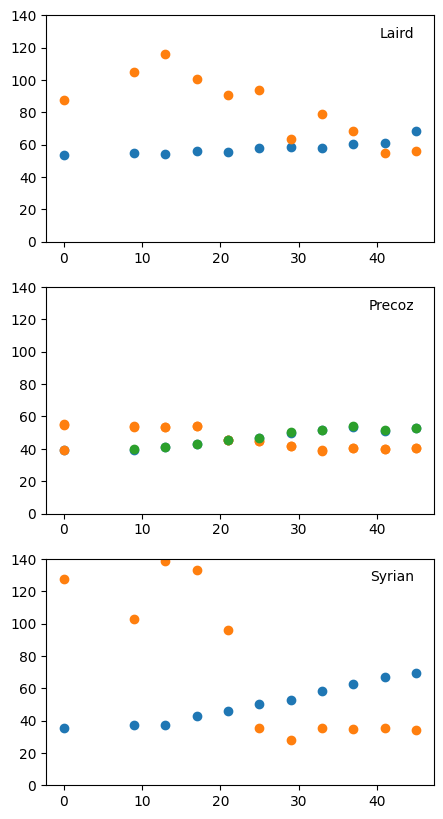

In [76]:
Graph = plt.figure(figsize=(5,10))
pos = 1
for c in Rob86Cults:
    ax = Graph.add_subplot(3,1,pos)
    plt.text(0.95,0.95,c,horizontalalignment='right',verticalalignment='top', transform=ax.transAxes)
    for ip in Rob86InitPps:
        datfilter = (Roberts86.Cultivar==c)&(Roberts86.PpInitial==ip)
        dat = Roberts86.loc[datfilter,:]
            # fc = cols[fp]
            # ls = lins[id]
            # if id == 0:
            #     fc = 'w'
        plt.plot(dat.DuratInitial,dat.DaysToFlowerPostVern,'o')#,ls,color = cols[fp],mfc=fc)
    #plt.ylim(ylims[c][0],ylims[c][1])
    plt.ylim(0,140)
    #plt.xlim(5,25)
    pos+=1